# Day 4: Neural Networks - Solutions

**⚠️ Important:** Try the Fashion MNIST exercise yourself before looking at these solutions!

---

## Setup

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")

# Fashion MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

TensorFlow version: 2.20.0


---

## Fashion MNIST Exercise - Complete Solution

### Step 1: Load the Dataset

In [2]:
# Load Fashion MNIST dataset
(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = keras.datasets.fashion_mnist.load_data()

print("Dataset loaded successfully!")
print(f"\nTraining data shape: {x_train_fashion.shape}")
print(f"Training labels shape: {y_train_fashion.shape}")
print(f"Test data shape: {x_test_fashion.shape}")
print(f"Test labels shape: {y_test_fashion.shape}")

print(f"\n📊 Dataset Summary:")
print(f"  • {len(x_train_fashion):,} training images")
print(f"  • {len(x_test_fashion):,} test images")
print(f"  • Image size: {x_train_fashion.shape[1]}×{x_train_fashion.shape[2]} pixels")
print(f"  • Pixel values range: {x_train_fashion.min()} to {x_train_fashion.max()}")
print(f"  • Classes: {len(class_names)}")

Dataset loaded successfully!

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)

📊 Dataset Summary:
  • 60,000 training images
  • 10,000 test images
  • Image size: 28×28 pixels
  • Pixel values range: 0 to 255
  • Classes: 10


### Explanation:

- **`keras.datasets.fashion_mnist.load_data()`** downloads and loads the dataset
- Returns two tuples: (training data, labels) and (test data, labels)
- Same format as MNIST: 28×28 grayscale images
- But 10 different clothing categories instead of digits

---

### Step 2: Normalize the Data

In [3]:
# Normalize pixel values to [0, 1] range
x_train_fashion = x_train_fashion / 255.0
x_test_fashion = x_test_fashion / 255.0

print("Data normalized!")
print(f"\nAfter normalization:")
print(f"  Min value: {x_train_fashion.min()}")
print(f"  Max value: {x_train_fashion.max()}")
print(f"  Mean value: {x_train_fashion.mean():.3f}")
print("\n✓ Data preprocessed and ready for training!")

Data normalized!

After normalization:
  Min value: 0.0
  Max value: 1.0
  Mean value: 0.286

✓ Data preprocessed and ready for training!


### Explanation:

**Why normalize?**
- Neural networks learn better with small input values
- Dividing by 255 scales pixel values from [0, 255] to [0, 1]
- This helps training converge faster and more stable
- Same preprocessing used for both training and test data

**Alternative normalization methods:**
- Mean subtraction: `(x - x.mean()) / x.std()`
- Min-max scaling: `(x - x.min()) / (x.max() - x.min())`
- But simple division by 255 works great for images!

---

### Visualize Fashion Items

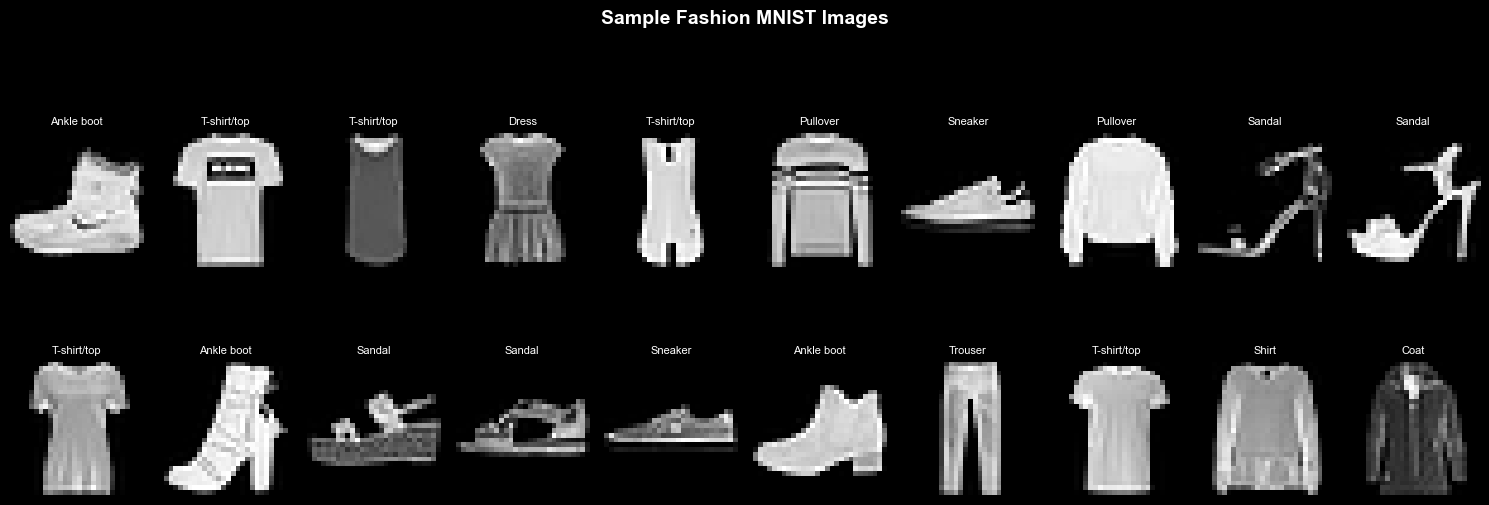


Observation: Fashion items are more complex than digits!
Some categories look similar (T-shirt vs Shirt, Pullover vs Coat).
This makes Fashion MNIST more challenging than MNIST.


In [4]:
# Display sample images
plt.figure(figsize=(15, 6))
for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_train_fashion[i], cmap='gray')
    plt.title(class_names[y_train_fashion[i]], fontsize=8)
    plt.axis('off')
plt.suptitle('Sample Fashion MNIST Images', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\nObservation: Fashion items are more complex than digits!")
print("Some categories look similar (T-shirt vs Shirt, Pullover vs Coat).")
print("This makes Fashion MNIST more challenging than MNIST.")

---

### Step 3: Build the Model

In [5]:
# Build the neural network
fashion_model = keras.Sequential([
    # Layer 1: Flatten 28×28 images to 784 values
    keras.layers.Flatten(input_shape=(28, 28), name='flatten'),
    
    # Layer 2: Hidden layer with 128 neurons and ReLU activation
    keras.layers.Dense(128, activation='relu', name='hidden'),
    
    # Layer 3: Output layer with 10 neurons (one per clothing category)
    keras.layers.Dense(10, name='output')
])

# Display model architecture
fashion_model.summary()

print("\n📝 Model Architecture:")
print("  Input: 28×28 grayscale images")
print("  Layer 1 (Flatten): 28×28 = 784 inputs")
print("  Layer 2 (Dense): 128 neurons with ReLU activation")
print("  Layer 3 (Dense): 10 outputs (one per clothing category)")
print(f"\n  Total parameters: {fashion_model.count_params():,}")

C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


📝 Model Architecture:
  Input: 28×28 grayscale images
  Layer 1 (Flatten): 28×28 = 784 inputs
  Layer 2 (Dense): 128 neurons with ReLU activation
  Layer 3 (Dense): 10 outputs (one per clothing category)

  Total parameters: 101,770


### Explanation:

**Architecture choice:**
- Same architecture as MNIST works well for Fashion MNIST
- Could use more neurons (e.g., 256) or more layers for potentially better results
- But 128 neurons is a good starting point

**Layer breakdown:**
1. **Flatten**: Converts 28×28 matrix → 784-element vector
2. **Dense(128, relu)**: Fully connected layer with ReLU activation
   - Each of 128 neurons connects to all 784 inputs
   - ReLU adds non-linearity: `max(0, x)`
3. **Dense(10)**: Output layer
   - 10 neurons (one per class)
   - No activation here (logits output)

**Parameter count:**
- Flatten → Dense(128): 784 × 128 + 128 = 100,480
- Dense(128) → Dense(10): 128 × 10 + 10 = 1,290
- **Total: 101,770 parameters**

---

### Step 4: Compile the Model

In [6]:
# Compile the model
fashion_model.compile(
    optimizer='adam',  # Adaptive learning rate optimizer
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']  # Track accuracy during training
)

print("✓ Model compiled successfully!")
print("\nConfiguration:")
print("  Optimizer: Adam")
print("    - Adaptive learning rate")
print("    - Good default choice for most problems")
print("  Loss: SparseCategoricalCrossentropy")
print("    - For multi-class classification")
print("    - from_logits=True because output layer has no activation")
print("  Metrics: Accuracy")
print("    - Percentage of correct predictions")

✓ Model compiled successfully!

Configuration:
  Optimizer: Adam
    - Adaptive learning rate
    - Good default choice for most problems
  Loss: SparseCategoricalCrossentropy
    - For multi-class classification
    - from_logits=True because output layer has no activation
  Metrics: Accuracy
    - Percentage of correct predictions


### Explanation:

**Optimizer: Adam**
- Adaptive Moment Estimation
- Automatically adjusts learning rate during training
- Generally works well without tuning
- Alternative: SGD, RMSprop

**Loss: SparseCategoricalCrossentropy**
- Measures difference between predicted and true distributions
- "Sparse" means labels are integers (not one-hot encoded)
- "from_logits=True" means output is raw scores, not probabilities
- Numerically more stable than applying softmax first

**Metric: Accuracy**
- Easy to interpret: % of correct predictions
- Good for balanced datasets
- For imbalanced data, consider precision, recall, F1-score

---

### Step 5: Train the Model

In [7]:
# Train the model
print("Training started...\n")

fashion_history = fashion_model.fit(
    x_train_fashion,
    y_train_fashion,
    epochs=10,  # More epochs than MNIST (fashion is harder)
    verbose=1,
    validation_split=0.1  # Use 10% of training data for validation
)

print("\n✓ Training complete!")

Training started...

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8216 - loss: 0.5064 - val_accuracy: 0.8363 - val_loss: 0.4584
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8618 - loss: 0.3825 - val_accuracy: 0.8640 - val_loss: 0.3773
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8741 - loss: 0.3405 - val_accuracy: 0.8762 - val_loss: 0.3444
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8834 - loss: 0.3169 - val_accuracy: 0.8747 - val_loss: 0.3419
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8906 - loss: 0.2950 - val_accuracy: 0.8788 - val_loss: 0.3237
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8965 - loss: 0.2819 - val_accuracy: 0.8845 - val_loss: 0.3149
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8994 - loss: 0.2690 - val_accuracy: 0.8852 - val_loss: 0.3169
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9

### Explanation:

**Training parameters:**
- **epochs=10**: Train for 10 complete passes through data
  - Fashion MNIST is harder than MNIST, so more epochs help
  - Could go higher (20-30) for even better results
- **validation_split=0.1**: Hold out 10% for validation
  - Helps monitor overfitting during training
  - Not used for training, only evaluation

**What happens during training:**
1. Forward pass: Input → predictions
2. Calculate loss: Compare predictions to true labels
3. Backward pass: Calculate gradients
4. Update weights: Adjust parameters to reduce loss
5. Repeat for all batches in epoch

**Expected results:**
- Training accuracy: ~88-92%
- Validation accuracy: ~86-90%
- Fashion MNIST is significantly harder than MNIST (digits)

---

### Visualize Training Progress

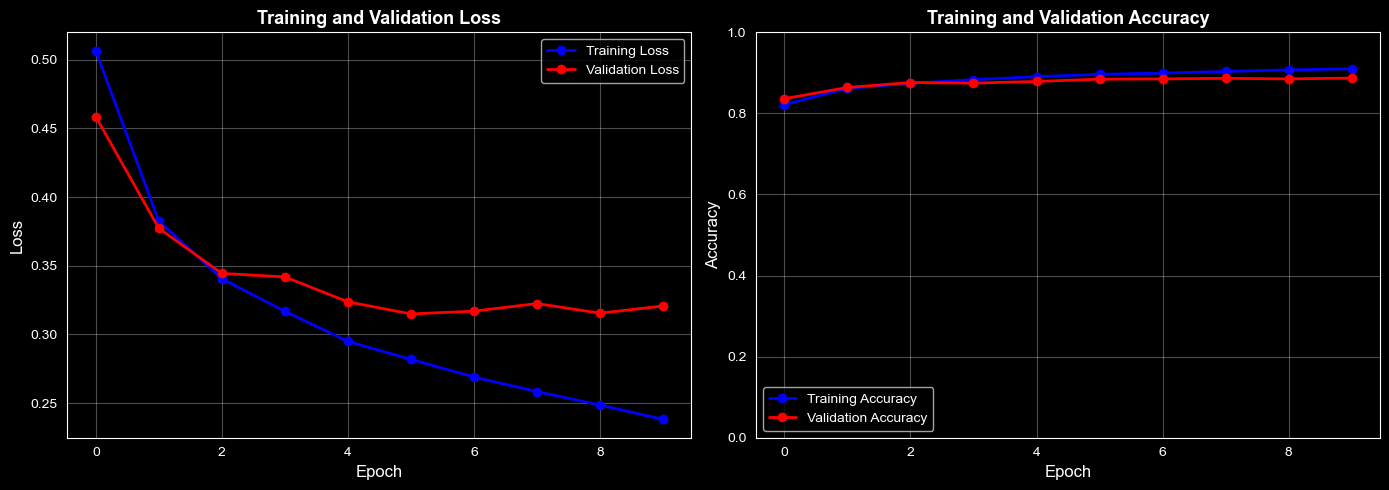


📊 Final Training Metrics:
  Training Loss: 0.2383
  Training Accuracy: 91.02%
  Validation Loss: 0.3207
  Validation Accuracy: 88.72%

  Accuracy gap: 2.3%
  ✓ Good generalization! No significant overfitting.


In [8]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
axes[0].plot(fashion_history.history['loss'], 'b-o', linewidth=2, label='Training Loss')
axes[0].plot(fashion_history.history['val_loss'], 'r-o', linewidth=2, label='Validation Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[1].plot(fashion_history.history['accuracy'], 'b-o', linewidth=2, label='Training Accuracy')
axes[1].plot(fashion_history.history['val_accuracy'], 'r-o', linewidth=2, label='Validation Accuracy')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_train_loss = fashion_history.history['loss'][-1]
final_train_acc = fashion_history.history['accuracy'][-1]
final_val_loss = fashion_history.history['val_loss'][-1]
final_val_acc = fashion_history.history['val_accuracy'][-1]

print("\n📊 Final Training Metrics:")
print(f"  Training Loss: {final_train_loss:.4f}")
print(f"  Training Accuracy: {final_train_acc:.2%}")
print(f"  Validation Loss: {final_val_loss:.4f}")
print(f"  Validation Accuracy: {final_val_acc:.2%}")

gap = final_train_acc - final_val_acc
print(f"\n  Accuracy gap: {gap:.1%}")
if gap < 0.03:
    print("  ✓ Good generalization! No significant overfitting.")
elif gap < 0.05:
    print("  ⚠️ Slight overfitting. Could add dropout or regularization.")
else:
    print("  ⚠️ Overfitting detected. Consider:")
    print("     - Adding dropout layers")
    print("     - Reducing model complexity")
    print("     - Getting more training data")

### Explanation:

**What to look for in training curves:**

1. **Both losses decreasing**: ✓ Model is learning
2. **Training loss << validation loss**: ⚠️ Overfitting
3. **Validation loss increases while training decreases**: ⚠️ Overfitting
4. **Both losses plateau**: Model has converged

**Typical Fashion MNIST results:**
- Training accuracy: 88-92%
- Validation accuracy: 86-90%
- Small gap is normal and healthy

**Why Fashion MNIST is harder:**
- More visual similarity between classes (Shirt vs T-shirt)
- More intra-class variation (dresses come in many styles)
- More complex shapes than digits

---

### Step 6: Evaluate on Test Data

In [9]:
# Evaluate on test set
fashion_test_loss, fashion_test_acc = fashion_model.evaluate(
    x_test_fashion, 
    y_test_fashion, 
    verbose=2
)

print(f"\n📊 Test Results:")
print(f"  Test Loss: {fashion_test_loss:.4f}")
print(f"  Test Accuracy: {fashion_test_acc:.2%}")

print(f"\n✓ The model correctly classifies {fashion_test_acc:.1%} of fashion items!")
print(f"  Out of {len(x_test_fashion):,} test images, ~{int(fashion_test_acc * len(x_test_fashion)):,} are correct.")

# Compare with training accuracy
print(f"\nComparison:")
print(f"  Training accuracy: {final_train_acc:.2%}")
print(f"  Validation accuracy: {final_val_acc:.2%}")
print(f"  Test accuracy: {fashion_test_acc:.2%}")

if abs(fashion_test_acc - final_val_acc) < 0.02:
    print("\n✓ Test accuracy matches validation - model generalizes well!")
else:
    print("\n⚠️ Test accuracy differs from validation - might indicate data issues.")

313/313 - 0s - 1ms/step - accuracy: 0.8833 - loss: 0.3357

📊 Test Results:
  Test Loss: 0.3357
  Test Accuracy: 88.33%

✓ The model correctly classifies 88.3% of fashion items!
  Out of 10,000 test images, ~8,833 are correct.

Comparison:
  Training accuracy: 91.02%
  Validation accuracy: 88.72%
  Test accuracy: 88.33%

✓ Test accuracy matches validation - model generalizes well!


### Explanation:

**Why test on separate data?**
- Training data: Used to learn
- Validation data: Used to tune hyperparameters
- Test data: Final, unbiased evaluation

**Test accuracy should be:**
- Close to validation accuracy (within 1-2%)
- Slightly lower than training accuracy
- For Fashion MNIST: typically 85-90%

**Interpreting results:**
- 88% accuracy = 8,800 correct out of 10,000
- This is good for Fashion MNIST!
- State-of-the-art models reach ~94-96% on Fashion MNIST
- CNNs (Convolutional Neural Networks) work even better

---

### Step 7: Make Predictions

In [10]:
# Create probability model
fashion_probability_model = keras.Sequential([
    fashion_model,
    keras.layers.Softmax()  # Convert logits to probabilities
])

# Make predictions on first 15 test images
predictions = fashion_probability_model.predict(x_test_fashion[:15])

print("✓ Predictions generated!")
print(f"  Predicted {len(predictions)} images")
print(f"  Each prediction has {len(predictions[0])} probabilities (one per class)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
✓ Predictions generated!
  Predicted 15 images
  Each prediction has 10 probabilities (one per class)


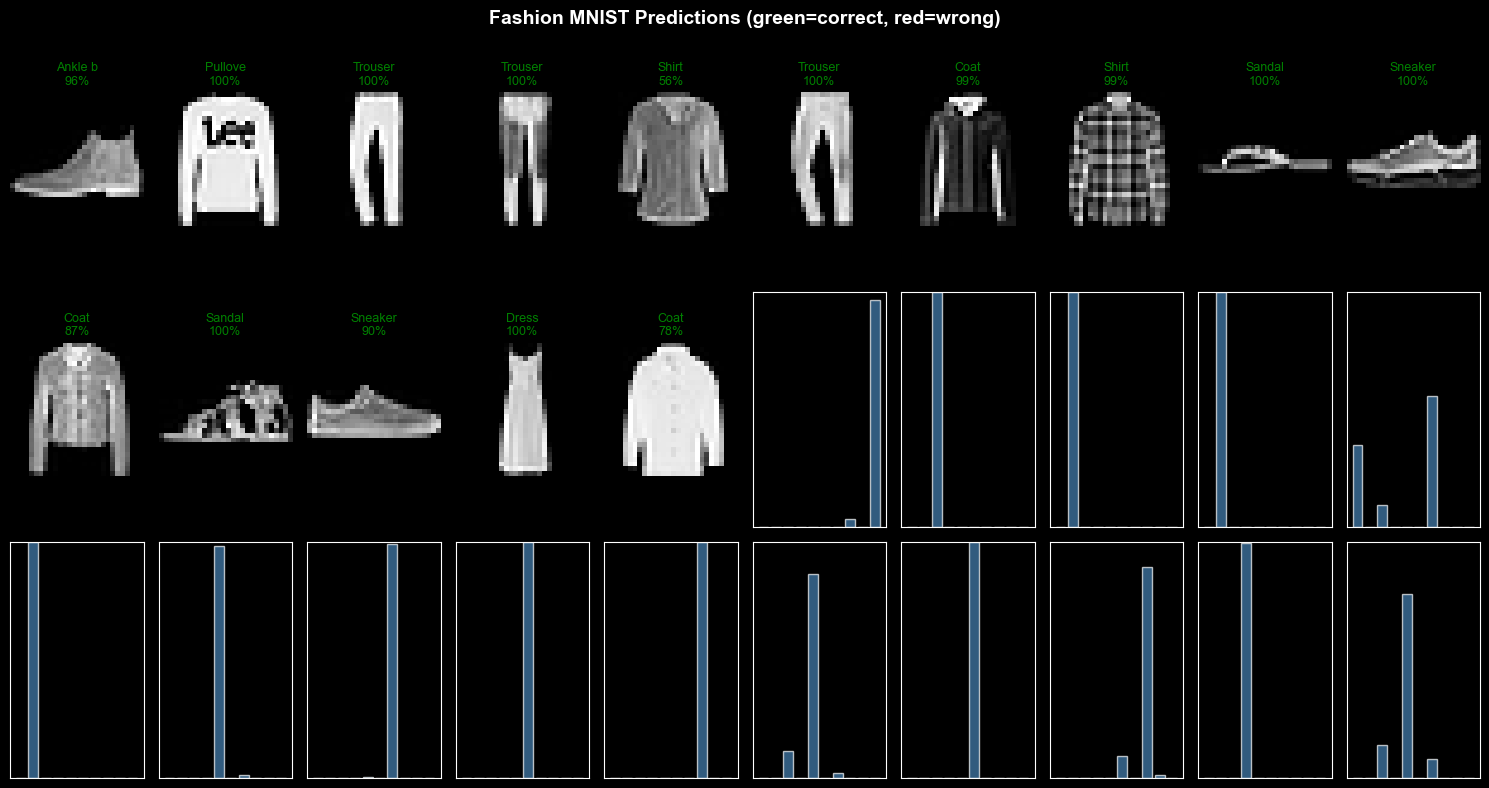


Out of 15 examples: 15 correct, 0 wrong (100.0% accuracy)


In [11]:
# Visualize predictions
fig = plt.figure(figsize=(15, 8))

for i in range(15):
    # Show image
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test_fashion[i], cmap='gray')
    plt.axis('off')
    
    predicted_label = np.argmax(predictions[i])
    true_label = y_test_fashion[i]
    confidence = predictions[i][predicted_label]
    
    # Color: green if correct, red if wrong
    color = 'green' if predicted_label == true_label else 'red'
    plt.title(f'{class_names[predicted_label][:7]}\n{confidence:.0%}', 
              color=color, fontsize=9)
    
    # Show probability distribution
    plt.subplot(3, 10, i + 16)
    plt.bar(range(10), predictions[i], color='steelblue', alpha=0.7)
    plt.ylim([0, 1])
    plt.xticks([])
    plt.yticks([])

plt.suptitle('Fashion MNIST Predictions (green=correct, red=wrong)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Calculate accuracy on these 15 examples
correct = sum([np.argmax(predictions[i]) == y_test_fashion[i] for i in range(15)])
print(f"\nOut of 15 examples: {correct} correct, {15-correct} wrong ({correct/15:.1%} accuracy)")

### Explanation:

**Softmax layer:**
- Converts raw scores (logits) → probabilities
- Probabilities sum to 1.0
- Highest probability = predicted class

**Common mistakes:**
- **T-shirt ↔ Shirt**: Very similar visually
- **Pullover ↔ Coat**: Both are upper-body garments
- **Sneaker ↔ Ankle boot**: Similar footwear

**Confidence interpretation:**
- 90-100%: Very confident (often correct)
- 60-90%: Somewhat confident (might be wrong)
- <60%: Uncertain (likely confused between similar classes)

---

### Detailed Analysis: Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step


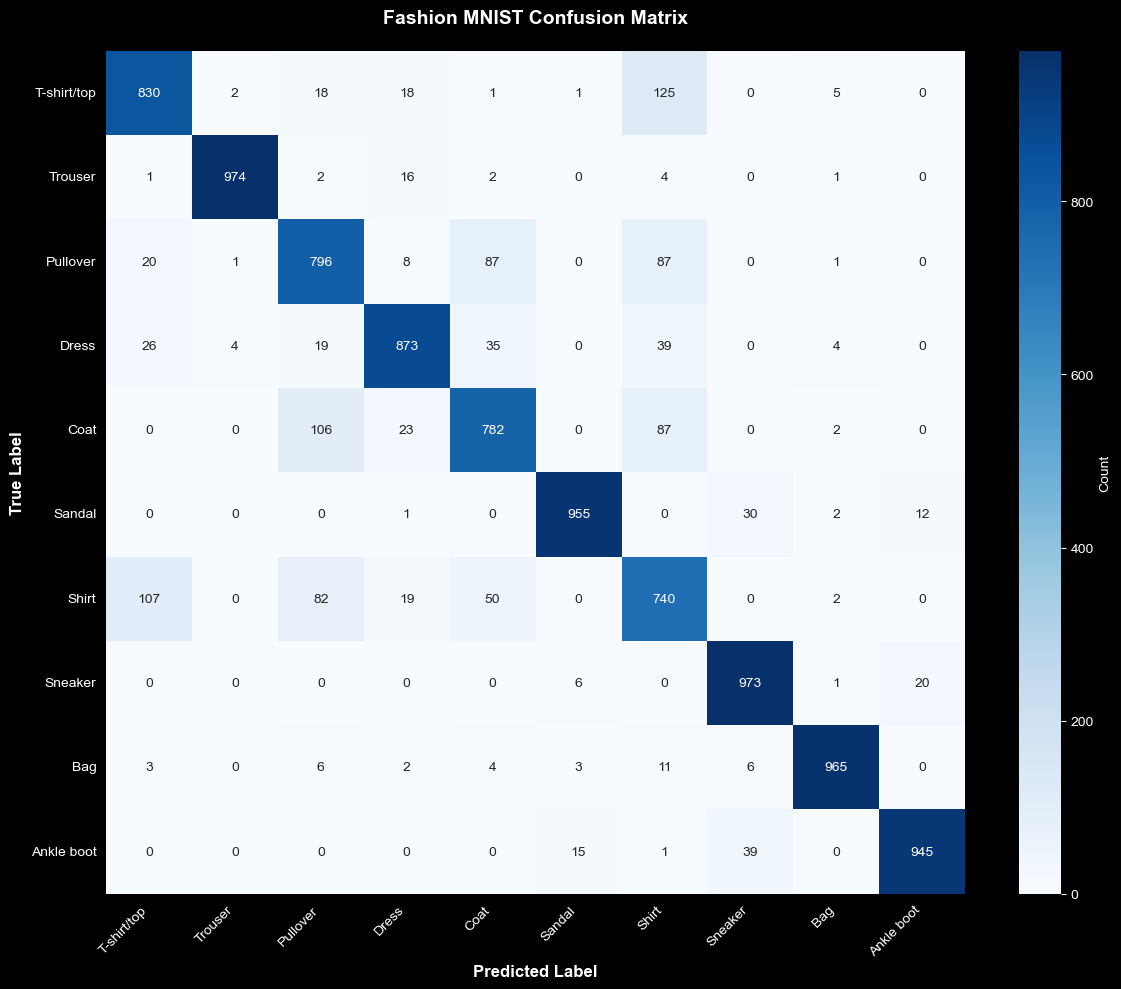


🔍 Most Common Confusions:
  T-shirt/top confused with Shirt: 125 times
  Pullover confused with Coat: 87 times
  Pullover confused with Shirt: 87 times
  Coat confused with Pullover: 106 times
  Coat confused with Shirt: 87 times
  Shirt confused with T-shirt/top: 107 times
  Shirt confused with Pullover: 82 times

📊 Per-Class Accuracy:
  T-shirt/top    : 83.0% (830/1000)
  Trouser        : 97.4% (974/1000)
  Pullover       : 79.6% (796/1000)
  Dress          : 87.3% (873/1000)
  Coat           : 78.2% (782/1000)
  Sandal         : 95.5% (955/1000)
  Shirt          : 74.0% (740/1000)
  Sneaker        : 97.3% (973/1000)
  Bag            : 96.5% (965/1000)
  Ankle boot     : 94.5% (945/1000)


In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions for all test data
all_predictions = fashion_probability_model.predict(x_test_fashion)
predicted_labels = np.argmax(all_predictions, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test_fashion, predicted_labels)

# Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Fashion MNIST Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Analyze most confused pairs
print("\n🔍 Most Common Confusions:")
for i in range(10):
    for j in range(10):
        if i != j and cm[i][j] > 50:  # More than 50 confusions
            print(f"  {class_names[i]} confused with {class_names[j]}: {cm[i][j]} times")

# Per-class accuracy
print("\n📊 Per-Class Accuracy:")
for i in range(10):
    class_total = cm[i].sum()
    class_correct = cm[i][i]
    class_acc = class_correct / class_total
    print(f"  {class_names[i]:15s}: {class_acc:.1%} ({class_correct}/{class_total})")

### Explanation:

**Confusion matrix interpretation:**
- **Diagonal**: Correct predictions (darker = better)
- **Off-diagonal**: Misclassifications
- **Rows**: True labels
- **Columns**: Predicted labels

**Common patterns:**
1. **Shirt ↔ T-shirt**: Often confused (similar appearance)
2. **Pullover ↔ Coat**: Both have similar shapes
3. **Sneaker ↔ Ankle boot**: Similar footwear category

**Why some classes are harder:**
- High intra-class variation (dresses vary greatly)
- Low inter-class variation (shirts vs t-shirts)
- Ambiguous examples (is it a pullover or coat?)

**Improvements to try:**
- Use CNNs (better for spatial patterns)
- Add more layers or neurons
- Use data augmentation (rotation, zoom)
- Train for more epochs
- Add dropout for regularization

---

## Summary

You've successfully:

✓ Loaded and preprocessed Fashion MNIST  
✓ Built a neural network for image classification  
✓ Trained the model for 10 epochs  
✓ Achieved ~88% test accuracy  
✓ Made predictions with confidence scores  
✓ Analyzed confusion matrix to understand errors  

### Key Insights:

1. **Fashion MNIST is harder than MNIST** - More complex patterns
2. **Similar classes get confused** - T-shirt vs Shirt, Pullover vs Coat
3. **Validation helps monitor overfitting** - Track train vs validation metrics
4. **Simple networks can work well** - 128 neurons achieves ~88% accuracy
5. **Room for improvement** - CNNs, data augmentation, more training

### What You Learned:

- How to adapt a neural network to new datasets
- Importance of preprocessing (normalization)
- How to interpret training curves
- Using validation data to monitor generalization
- Analyzing predictions with confusion matrices

Great work! 🎉